# Thai Sign Language Dataset — Preprocessing Pipeline

**Purpose:** Convert raw videos into normalized keypoint sequences for model training.

| Stage | Description |
|-------|-------------|
| 1 | Human Centering & Cropping (`raws` → `cutting`) |
| 2 | Cropping Validation |
| 3 | MediaPipe Landmark Visualization (`cutting` → `mediapipe`) |
| 4 | Visualization Validation |
| 5 | Keypoint Extraction |
| 6 | Confidence Features |
| 7 | Keypoint Normalization |
| 8 | Data Augmentation (train only) |
| 9 | Dataset Split |
| 10 | Save Processed Dataset (`→ processed/`) |


---
## Cell 0 — Imports & Configuration


In [ ]:
import json
import re
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.signal import savgol_filter
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

RAW_DIR       = Path('../datasets/raws')
CUTTING_DIR   = Path('../datasets/cutting')
MEDIAPIPE_DIR = Path('../datasets/mediapipe')
PROCESSED_DIR = Path('../datasets/processed')
LOGS_DIR      = Path('../logs/preprocessing')

for _d in [CUTTING_DIR, MEDIAPIPE_DIR, PROCESSED_DIR, LOGS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

TARGET_SIZE   = 600
TARGET_FRAMES = 240

POSE_MARGIN   = 0.35
SMOOTH_WINDOW = 7
SMOOTH_POLY   = 2

UPPER_BODY_POSE_IDX = [0, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
N_HAND_LM  = 21
N_POSE_LM  = len(UPPER_BODY_POSE_IDX)
HAND_FEAT  = N_HAND_LM * 3
POSE_FEAT  = N_POSE_LM * 3
TOTAL_FEAT = HAND_FEAT * 2 + POSE_FEAT
CONF_FEAT  = N_POSE_LM + 2

P2_START, P2_END = 2,  31
P3_START, P3_END = 32, 60

N_AUG_VARIANTS = 3
SPEED_JITTER   = 0.15
SCALE_JITTER   = 0.05
TRANS_JITTER   = 0.05
ROT_JITTER     = 5.0
NOISE_STD      = 0.005

mp_pose           = mp.solutions.pose
mp_holistic       = mp.solutions.holistic
mp_drawing        = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

print('Configuration loaded.')
print(f'  RAW_DIR       : {RAW_DIR.resolve()}')
print(f'  CUTTING_DIR   : {CUTTING_DIR.resolve()}')
print(f'  MEDIAPIPE_DIR : {MEDIAPIPE_DIR.resolve()}')
print(f'  PROCESSED_DIR : {PROCESSED_DIR.resolve()}')
print(f'  LOGS_DIR      : {LOGS_DIR.resolve()}')
print(f'  Keypoint features / frame : {TOTAL_FEAT}  (L-hand {HAND_FEAT} + R-hand {HAND_FEAT} + pose {POSE_FEAT})')
print(f'  Confidence features / frame : {CONF_FEAT}')


Configuration loaded.
  RAW_DIR       : C:\Users\Napat\termtemsl\experiment_model\datasets\raws
  CUTTING_DIR   : C:\Users\Napat\termtemsl\experiment_model\datasets\cutting
  MEDIAPIPE_DIR : C:\Users\Napat\termtemsl\experiment_model\datasets\mediapipe
  PROCESSED_DIR : C:\Users\Napat\termtemsl\experiment_model\datasets\processed
  LOGS_DIR      : C:\Users\Napat\termtemsl\experiment_model\logs\preprocessing
  Keypoint features / frame : 171  (L-hand 63 + R-hand 63 + pose 45)
  Confidence features / frame : 17


---
## Helper Functions


In [8]:
import re as _re

def discover_classes(raw_dir: Path) -> list:
    names = []
    for p in raw_dir.glob('*.mp4'):
        if not _re.search(r'_\d+$', p.stem):
            names.append(p.stem)
    return sorted(names)


def parse_video_path(p: Path) -> dict:
    m = _re.match(r'^(.+)_(\d+)$', p.stem)
    if m:
        word, idx = m.group(1), int(m.group(2))
    else:
        word, idx = p.stem, 1
    if idx == 1:
        person = 1
    elif P2_START <= idx <= P2_END:
        person = 2
    elif P3_START <= idx <= P3_END:
        person = 3
    else:
        person = -1
    return {'path': p, 'class': word, 'index': idx, 'person': person}


def collect_all_videos(directory: Path) -> pd.DataFrame:
    records = [parse_video_path(p) for p in sorted(directory.glob('*.mp4'))]
    return pd.DataFrame(records)


def sample_frames(path: Path, n_samples: int = 6) -> list:
    cap = cv2.VideoCapture(str(path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return []
    indices = np.linspace(0, total - 1, n_samples, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, float(idx))
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames


def show_video_strip(title: str, path: Path, n_samples: int = 5, cell_h: float = 3.0):
    frames = sample_frames(path, n_samples)
    if not frames:
        print(f'  [MISSING] {path}')
        return
    h, w = frames[0].shape[:2]
    ratio = w / h if h > 0 else 1.0
    fig, axes = plt.subplots(1, len(frames), figsize=(len(frames) * cell_h * ratio, cell_h))
    if len(frames) == 1:
        axes = [axes]
    for ax, fr in zip(axes, frames):
        ax.imshow(fr)
        ax.axis('off')
    fig.suptitle(title, fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()


def resample_sequence(seq: np.ndarray, target_len: int) -> np.ndarray:
    n = len(seq)
    if n == target_len:
        return seq
    old_idx = np.linspace(0, n - 1, n)
    new_idx = np.linspace(0, n - 1, target_len)
    return np.stack(
        [np.interp(new_idx, old_idx, seq[:, i]) for i in range(seq.shape[1])],
        axis=1
    )


classes = discover_classes(RAW_DIR)
print(f'Classes ({len(classes)}): {classes}')


Classes (10): ['ขอโทษ', 'ดี', 'สวัสดี', 'อะไร', 'เงิน', 'โทรศัพท์', 'ใคร', 'ใช่', 'ไม่', 'ไม่ดี']


---
## Stage 1 — Human Centering & Cropping

1. MediaPipe Pose detects the signer per frame.  
2. Body centre is estimated from visible upper-body landmarks.  
3. Bounding boxes are temporally smoothed (Savitzky-Golay) to remove jitter.  
4. Each frame is padded, cropped, and resized to `TARGET_SIZE × TARGET_SIZE`.  

Output → `datasets/cutting/`


In [ ]:
def _get_pose_bbox(landmarks, frame_h: int, frame_w: int, margin: float = 0.35):
    """
    Return (cx, cy, bw, bh) in pixels from MediaPipe pose landmarks.
    Returns None when too few landmarks are visible.
    """
    if landmarks is None:
        return None
    xs, ys = [], []
    for lm in landmarks.landmark:
        if lm.visibility > 0.3:
            xs.append(lm.x * frame_w)
            ys.append(lm.y * frame_h)
    if len(xs) < 3:
        return None
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    bw = x_max - x_min
    bh = y_max - y_min
    x_min -= bw * margin
    x_max += bw * margin
    y_min -= bh * margin * 1.1
    y_max += bh * margin * 0.4
    cx = (x_min + x_max) / 2.0
    cy = (y_min + y_max) / 2.0
    return cx, cy, x_max - x_min, y_max - y_min


def _fill_missing_bboxes(bboxes: list, frame_w: int, frame_h: int) -> list:
    """Forward-fill then backward-fill None entries; fallback to frame centre."""
    result = list(bboxes)
    last = None
    for i, b in enumerate(result):
        if b is not None:
            last = b
        elif last is not None:
            result[i] = last
    last = None
    for i in range(len(result) - 1, -1, -1):
        if result[i] is not None:
            last = result[i]
        elif last is not None:
            result[i] = last
    fallback = (frame_w / 2.0, frame_h / 2.0, frame_w * 0.85, frame_h * 0.85)
    return [b if b is not None else fallback for b in result]


def _smooth_bbox_array(arr: np.ndarray, window: int, poly: int) -> np.ndarray:
    n = len(arr)
    if n < window:
        return arr
    w = window if window % 2 == 1 else window - 1
    w = min(w, n if n % 2 == 1 else n - 1)
    smoothed = arr.copy()
    for i in range(arr.shape[1]):
        smoothed[:, i] = savgol_filter(arr[:, i], w, poly)
    return smoothed


def process_video_centering(
    input_path: Path,
    output_path: Path,
    target_size: int = TARGET_SIZE,
    margin: float = POSE_MARGIN,
    smooth_window: int = SMOOTH_WINDOW,
    smooth_poly: int = SMOOTH_POLY,
    overwrite: bool = False,
) -> dict:
    """Center signer and crop to target_size x target_size. Returns stats dict."""
    if not overwrite and output_path.exists():
        return {'success': True, 'skipped': True}

    cap = cv2.VideoCapture(str(input_path))
    if not cap.isOpened():
        return {'success': False, 'reason': 'cannot open'}

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    fw  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    fh  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    frames, raw_bboxes = [], []
    with mp_pose.Pose(
        static_image_mode=False,
        model_complexity=1,
        smooth_landmarks=True,
        min_detection_confidence=0.4,
        min_tracking_confidence=0.4,
    ) as pose_model:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)
            results = pose_model.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            raw_bboxes.append(_get_pose_bbox(results.pose_landmarks, fh, fw, margin))
    cap.release()

    if not frames:
        return {'success': False, 'reason': 'no frames'}

    n_frames   = len(frames)
    n_detected = sum(1 for b in raw_bboxes if b is not None)

    filled = _fill_missing_bboxes(raw_bboxes, fw, fh)
    bbox_arr = np.array(filled, dtype=float)
    bbox_arr = _smooth_bbox_array(bbox_arr, smooth_window, smooth_poly)

    sizes    = np.maximum(bbox_arr[:, 2], bbox_arr[:, 3])
    crop_sz  = int(np.percentile(sizes, 90))
    crop_sz  = max(crop_sz, target_size)   # never smaller than target
    half     = crop_sz // 2

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out    = cv2.VideoWriter(str(output_path), fourcc, fps, (target_size, target_size))

    for frame, bbox in zip(frames, bbox_arr):
        cx, cy = int(round(bbox[0])), int(round(bbox[1]))
        x1, y1 = cx - half, cy - half
        x2, y2 = cx + half, cy + half

        pad_l = max(0, -x1)
        pad_t = max(0, -y1)
        pad_r = max(0, x2 - fw)
        pad_b = max(0, y2 - fh)

        if pad_l or pad_t or pad_r or pad_b:
            frame = cv2.copyMakeBorder(
                frame, pad_t, pad_b, pad_l, pad_r,
                cv2.BORDER_CONSTANT, value=(0, 0, 0)
            )
            x1 += pad_l; x2 += pad_l
            y1 += pad_t; y2 += pad_t

        cropped = frame[y1:y2, x1:x2]
        out.write(cv2.resize(cropped, (target_size, target_size)))

    out.release()
    return {
        'success': True, 'skipped': False,
        'n_frames': n_frames,
        'n_detected': n_detected,
        'detection_rate': round(n_detected / n_frames, 4),
        'crop_size': crop_sz,
    }

print('Stage 1 helpers loaded.')


Stage 1 helpers loaded.


In [ ]:
df_raw = collect_all_videos(RAW_DIR)
stage1_stats = []

for _, row in tqdm(df_raw.iterrows(), total=len(df_raw), desc='Stage 1 — centering'):
    in_path  = row['path']
    out_path = CUTTING_DIR / in_path.name
    stat = process_video_centering(in_path, out_path)
    stat.update({'class': row['class'], 'person': row['person'], 'index': row['index']})
    stage1_stats.append(stat)

df_s1 = pd.DataFrame(stage1_stats)
ok  = df_s1[df_s1['success'] == True]
skp = df_s1[df_s1.get('skipped', False) == True] if 'skipped' in df_s1.columns else pd.DataFrame()

print(f'Processed : {len(ok)} / {len(df_s1)}')
if 'detection_rate' in df_s1.columns:
    valid = df_s1['detection_rate'].dropna()
    print(f'Detection rate  — mean: {valid.mean():.3f}  min: {valid.min():.3f}  max: {valid.max():.3f}')

poor = df_s1[df_s1.get('detection_rate', pd.Series(dtype=float)) < 0.5]
if 'detection_rate' in df_s1.columns:
    poor = df_s1[df_s1['detection_rate'].fillna(1.0) < 0.5]
    print(f'\nVideos with <50 % pose detection: {len(poor)}')
    if not poor.empty:
        print(poor[['class', 'person', 'index', 'detection_rate']].to_string(index=False))


Stage 1 — centering:   0%|          | 0/600 [00:00<?, ?it/s]

Processed : 600 / 600


IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

---
## Stage 2 — Cropping Validation

Display `word.mp4`, `word_02.mp4`, `word_31.mp4` for every class to verify centering.


In [1]:
VALIDATE_SUFFIXES = [
    ('',    'P1'),
    ('_02', 'P2'),
    ('_32', 'P3'),
]
N_PREVIEW = 5
_SEP = '─' * 60

for cls in classes:
    print(f'\n{_SEP}')
    print(f'Class: {cls}')
    for suffix, label in VALIDATE_SUFFIXES:
        vid = CUTTING_DIR / f'{cls}{suffix}.mp4'
        show_video_strip(f'{cls}{suffix}.mp4  ({label})', vid, N_PREVIEW)


NameError: name 'classes' is not defined

---
## Stage 3 — MediaPipe Landmark Visualization

Runs **MediaPipe Holistic** on every cropped video and draws:
- Right hand landmarks (red)
- Left hand landmarks (blue)
- Upper-body pose skeleton (green)

Output → `datasets/mediapipe/`


In [10]:
_POSE_CONN = frozenset([
    (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),
    (11, 23), (12, 24), (23, 24),
    (15, 17), (15, 19), (15, 21), (16, 18), (16, 20), (16, 22),
])
_HAND_CONN = mp_holistic.HAND_CONNECTIONS

_LHAND_STYLE  = mp_drawing.DrawingSpec(color=(220,  50,  50), thickness=2, circle_radius=2)
_RHAND_STYLE  = mp_drawing.DrawingSpec(color=( 50,  50, 220), thickness=2, circle_radius=2)
_LCONN_STYLE  = mp_drawing.DrawingSpec(color=(200,  80,  80), thickness=1)
_RCONN_STYLE  = mp_drawing.DrawingSpec(color=( 80,  80, 200), thickness=1)
_POSE_LSTYLE  = mp_drawing.DrawingSpec(color=(  0, 180,   0), thickness=2, circle_radius=3)
_POSE_CSTYLE  = mp_drawing.DrawingSpec(color=(  0, 140,   0), thickness=2)


def draw_holistic_frame(frame_bgr: np.ndarray, results) -> np.ndarray:
    out = frame_bgr.copy()
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            out, results.pose_landmarks,
            connections=_POSE_CONN,
            landmark_drawing_spec=_POSE_LSTYLE,
            connection_drawing_spec=_POSE_CSTYLE,
        )
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            out, results.left_hand_landmarks, _HAND_CONN,
            _LHAND_STYLE, _LCONN_STYLE,
        )
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            out, results.right_hand_landmarks, _HAND_CONN,
            _RHAND_STYLE, _RCONN_STYLE,
        )
    return out


def process_video_visualization(
    input_path: Path,
    output_path: Path,
    overwrite: bool = False,
) -> dict:
    if not overwrite and output_path.exists():
        return {'success': True, 'skipped': True}

    cap = cv2.VideoCapture(str(input_path))
    if not cap.isOpened():
        return {'success': False, 'reason': 'cannot open'}

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    fw  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    fh  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (fw, fh))

    n_lh = n_rh = n_pose = 0
    n_frames = 0

    with mp_holistic.Holistic(
        static_image_mode=False,
        model_complexity=1,
        smooth_landmarks=True,
        refine_face_landmarks=False,
        min_detection_confidence=0.4,
        min_tracking_confidence=0.4,
    ) as holistic:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            n_frames += 1
            results = holistic.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            n_lh   += results.left_hand_landmarks  is not None
            n_rh   += results.right_hand_landmarks is not None
            n_pose += results.pose_landmarks       is not None
            writer.write(draw_holistic_frame(frame, results))

    cap.release()
    writer.release()
    return {
        'success': True, 'skipped': False,
        'n_frames': n_frames,
        'lh_rate':   round(n_lh   / max(n_frames, 1), 4),
        'rh_rate':   round(n_rh   / max(n_frames, 1), 4),
        'pose_rate': round(n_pose / max(n_frames, 1), 4),
    }


print('Stage 3 helpers loaded.')


Stage 3 helpers loaded.


In [11]:
df_cut = collect_all_videos(CUTTING_DIR)
stage3_stats = []

for _, row in tqdm(df_cut.iterrows(), total=len(df_cut), desc='Stage 3 — visualization'):
    in_path  = row['path']
    out_path = MEDIAPIPE_DIR / in_path.name
    stat = process_video_visualization(in_path, out_path)
    stat.update({'class': row['class'], 'person': row['person'], 'index': row['index']})
    stage3_stats.append(stat)

df_s3 = pd.DataFrame(stage3_stats)
print(f'Visualized : {len(df_s3[df_s3["success"] == True])} / {len(df_s3)}')
if 'lh_rate' in df_s3.columns:
    for col, lbl in [('lh_rate', 'Left hand'), ('rh_rate', 'Right hand'), ('pose_rate', 'Pose')]:
        v = df_s3[col].dropna()
        print(f'  {lbl:12s} detection rate — mean: {v.mean():.3f}  min: {v.min():.3f}')


Stage 3 — visualization:   0%|          | 0/600 [00:00<?, ?it/s]

Visualized : 600 / 600


---
## Stage 4 — Visualization Validation

Spot-check mediapipe output: `word.mp4`, `word_02.mp4`, `word_31.mp4` for every class.



────────────────────────────────────────────────────────────
Class: ขอโทษ


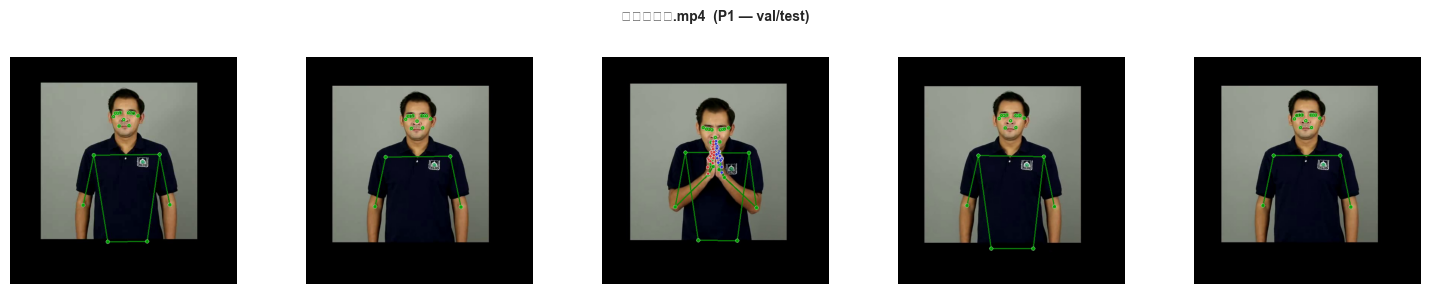

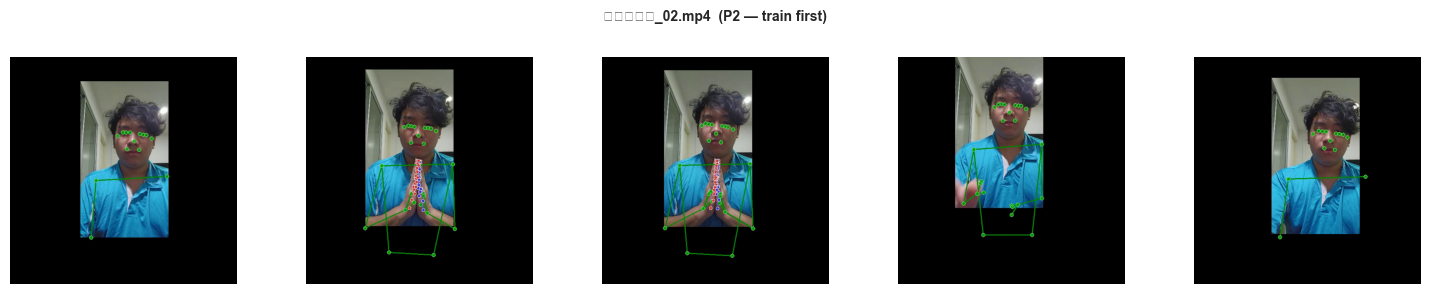

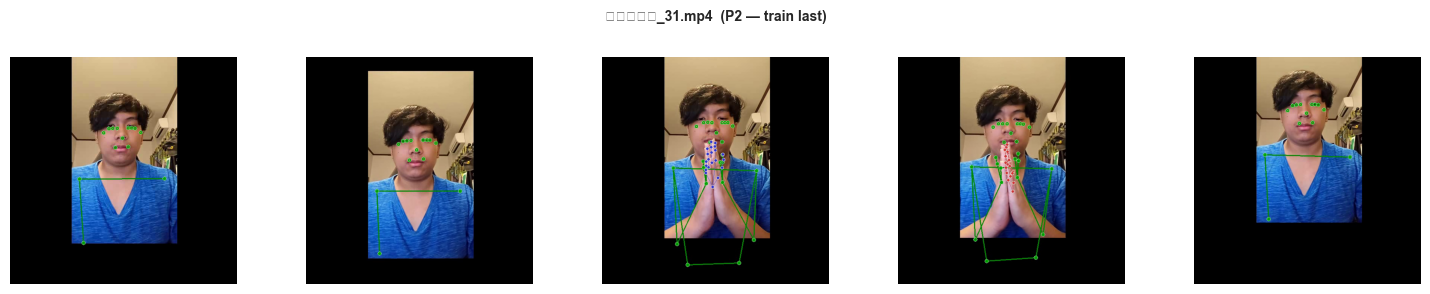


────────────────────────────────────────────────────────────
Class: ดี


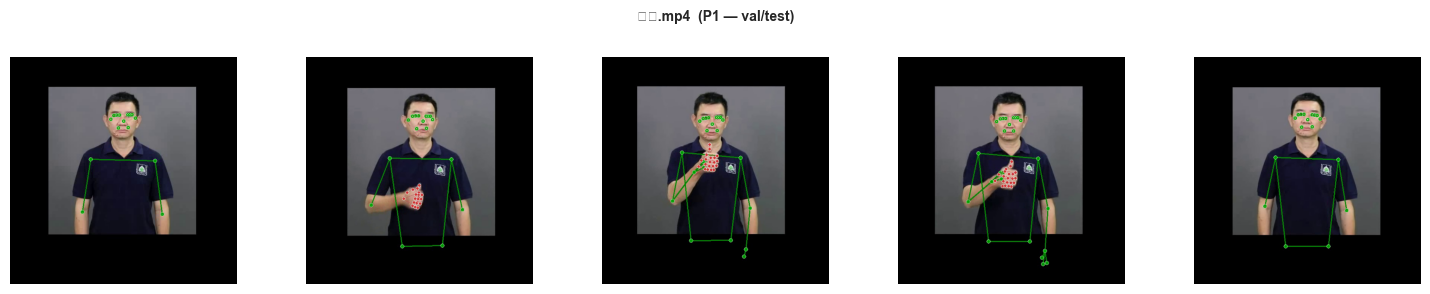

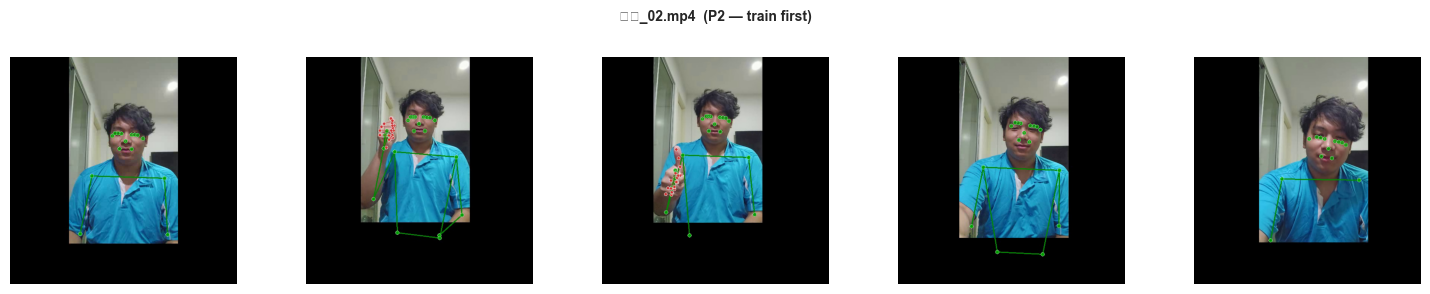

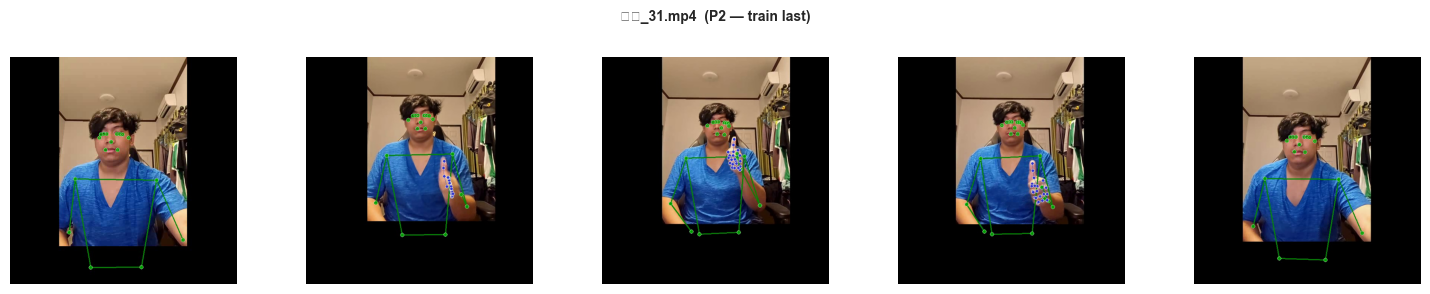


────────────────────────────────────────────────────────────
Class: สวัสดี


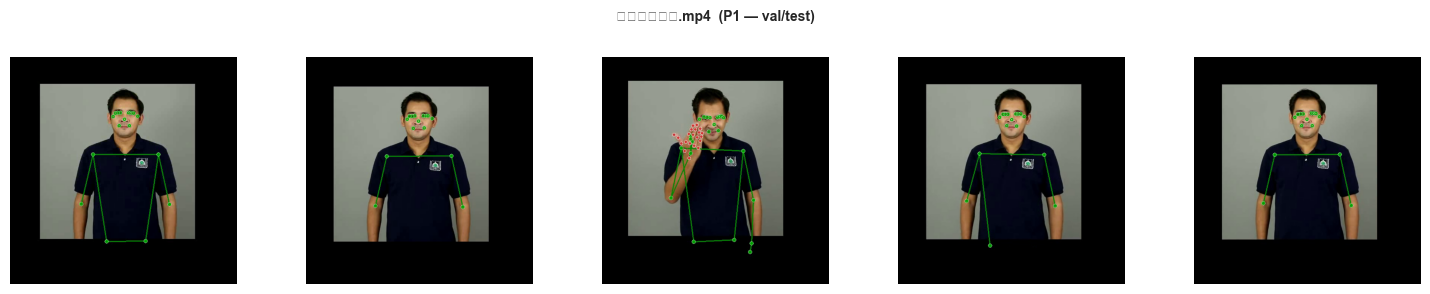

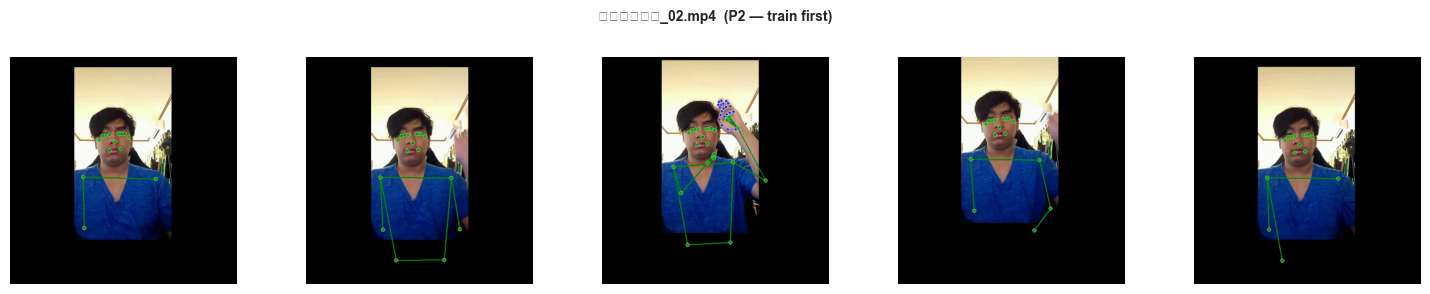

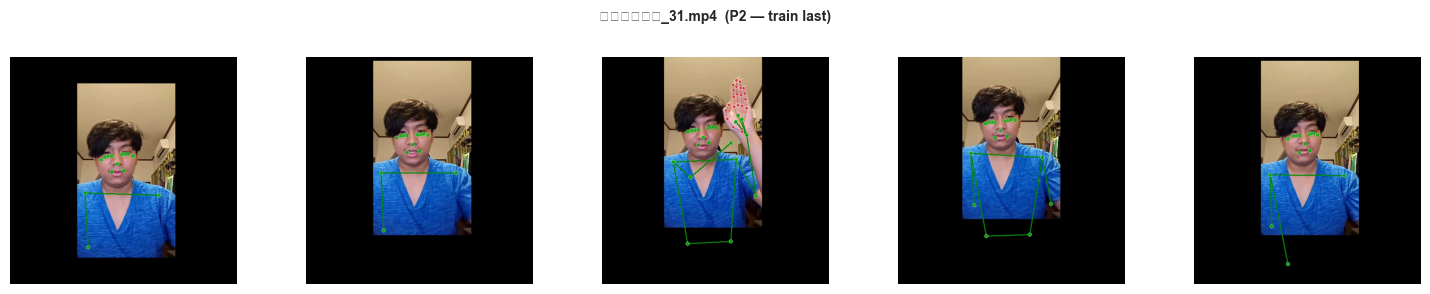


────────────────────────────────────────────────────────────
Class: อะไร


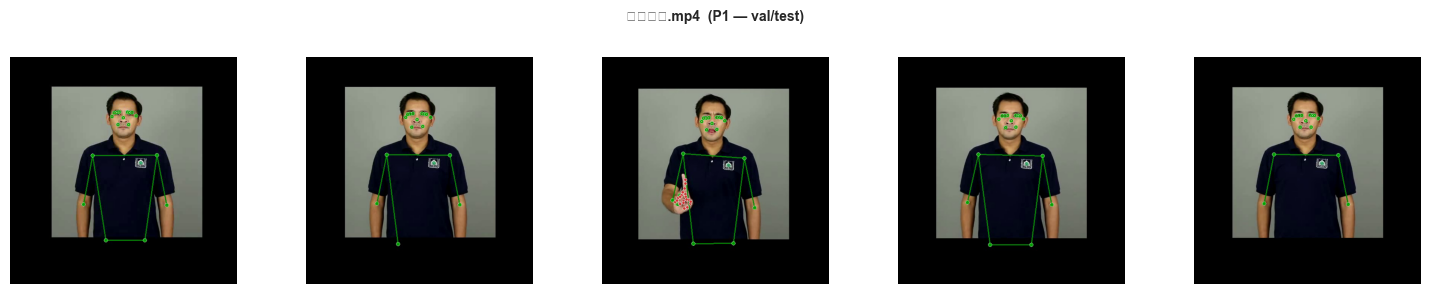

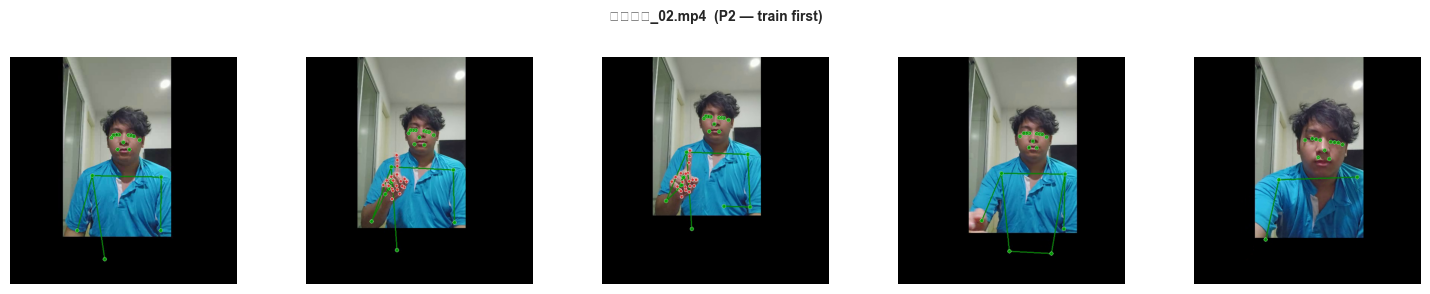

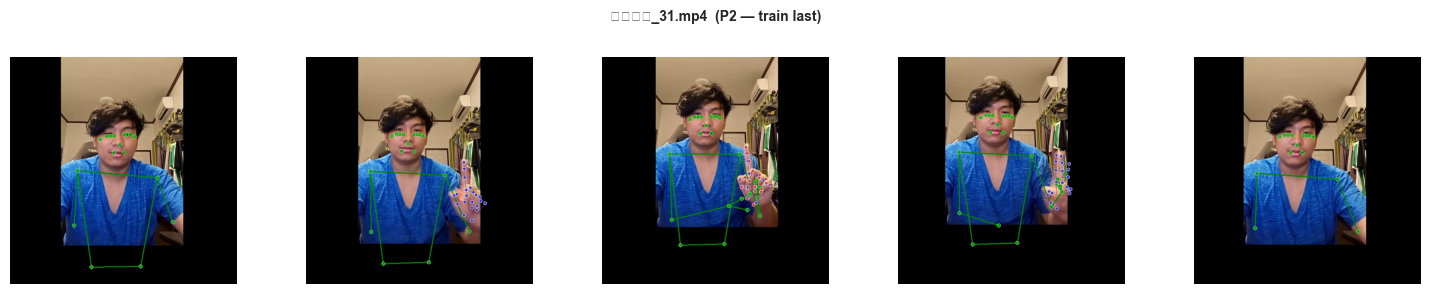


────────────────────────────────────────────────────────────
Class: เงิน


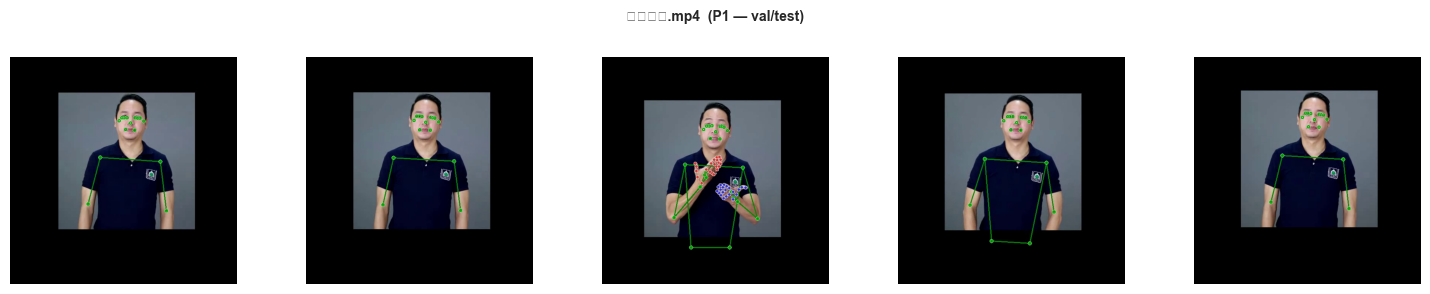

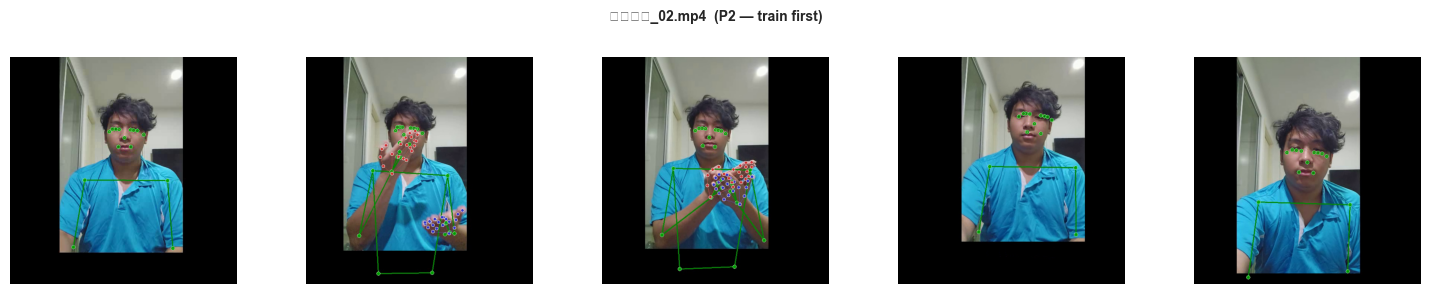

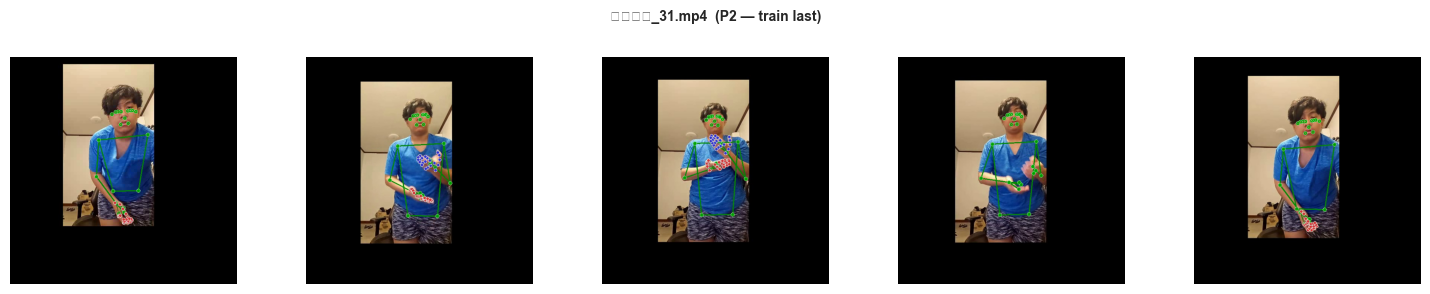


────────────────────────────────────────────────────────────
Class: โทรศัพท์


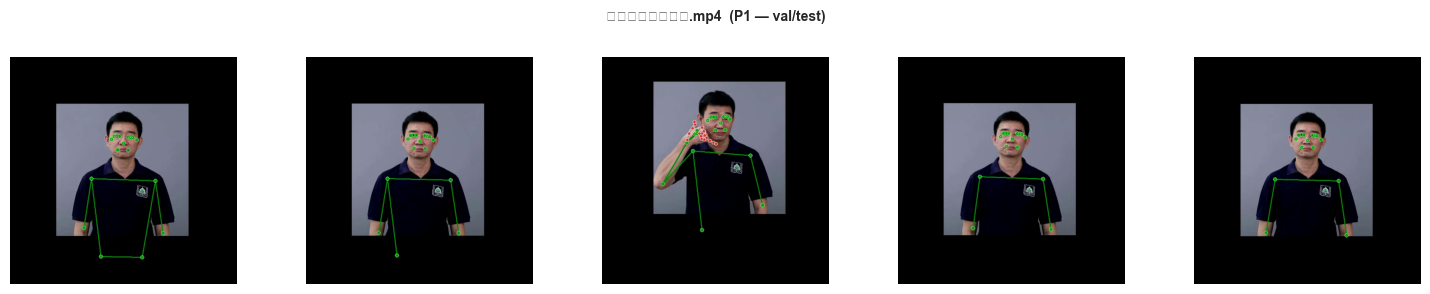

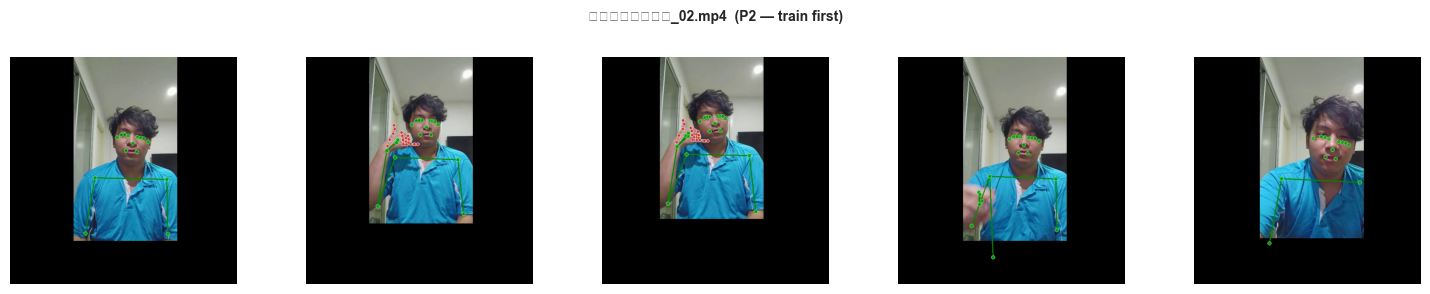

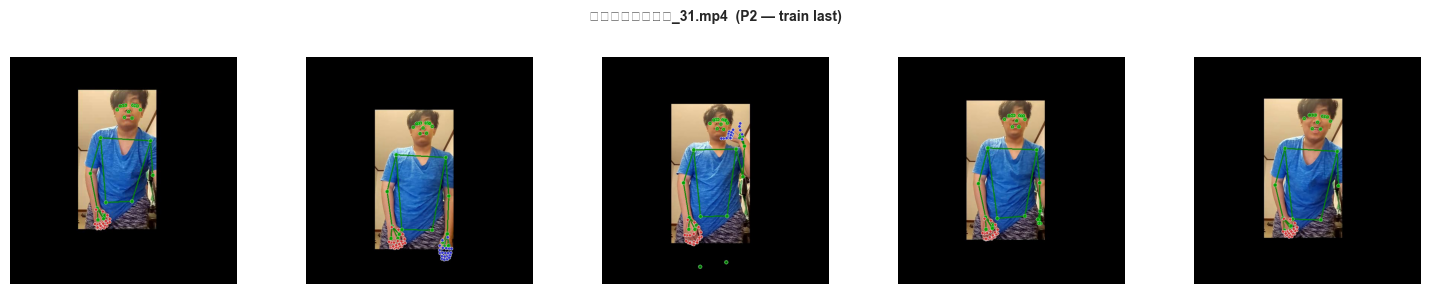


────────────────────────────────────────────────────────────
Class: ใคร


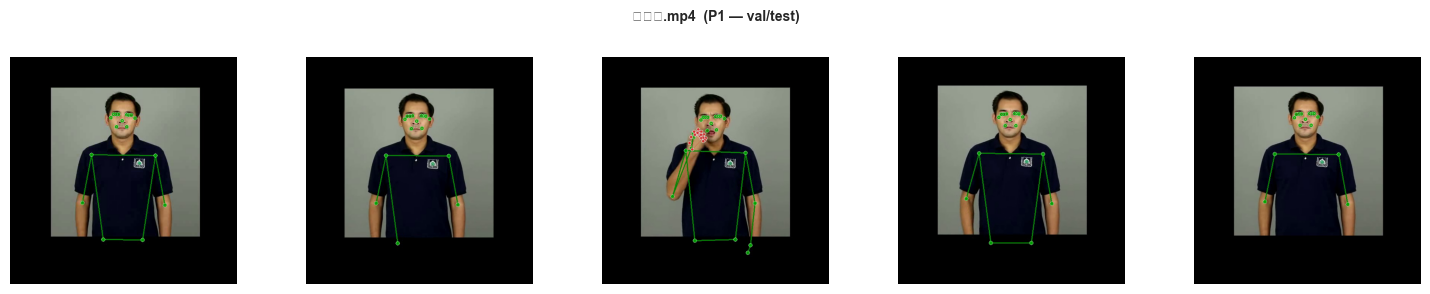

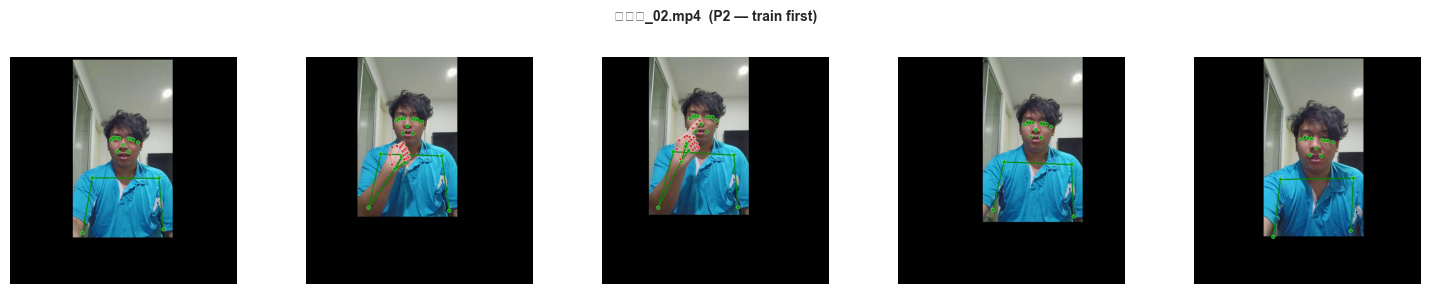

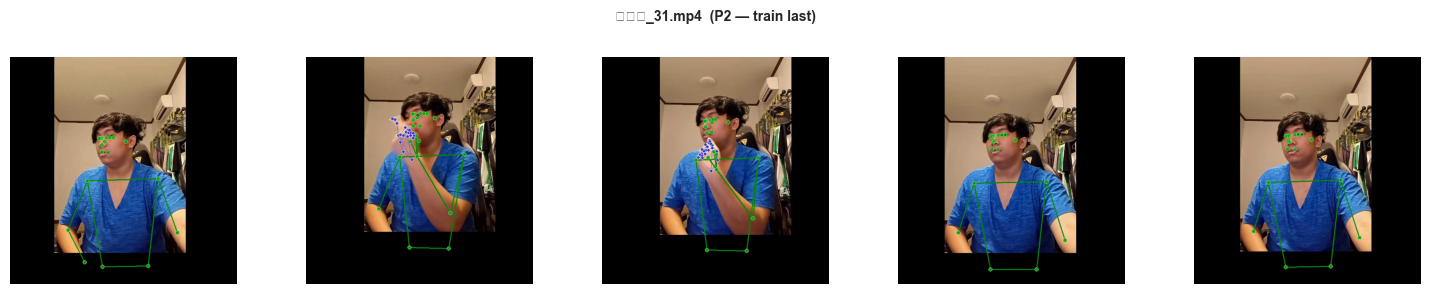


────────────────────────────────────────────────────────────
Class: ใช่


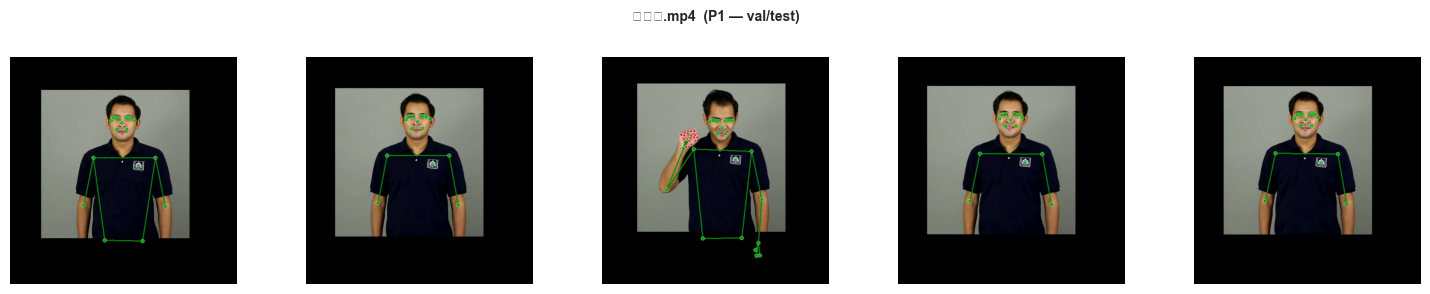

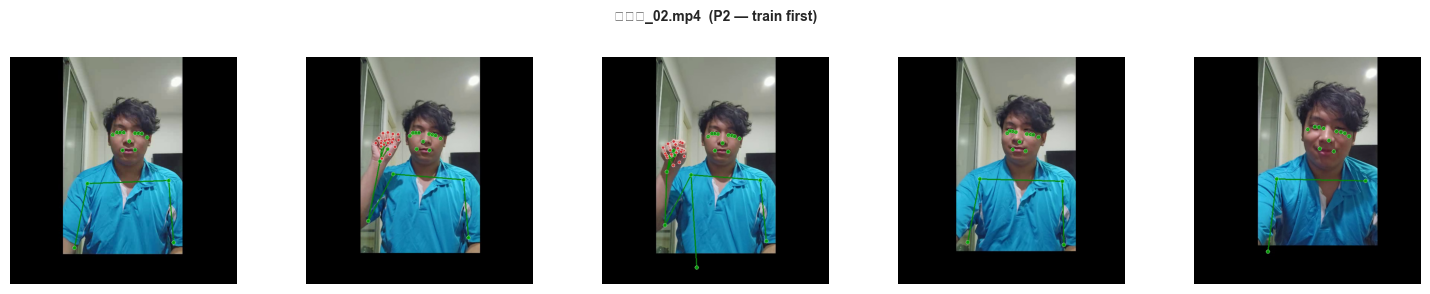

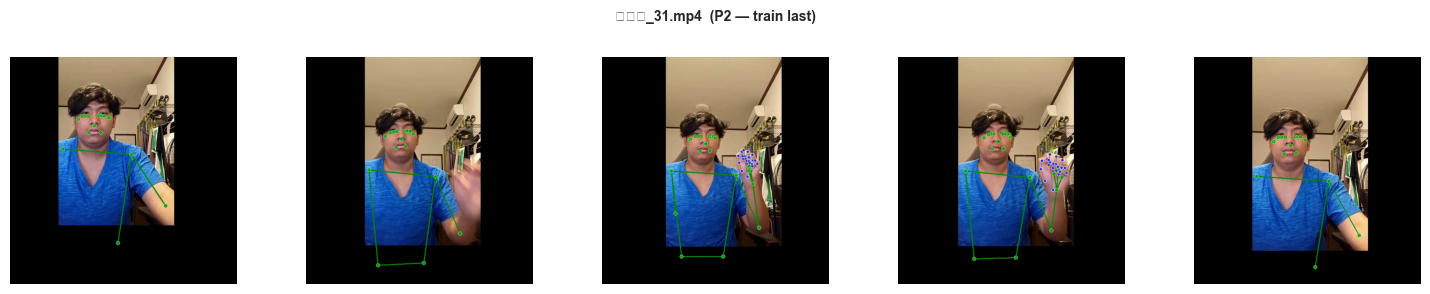


────────────────────────────────────────────────────────────
Class: ไม่


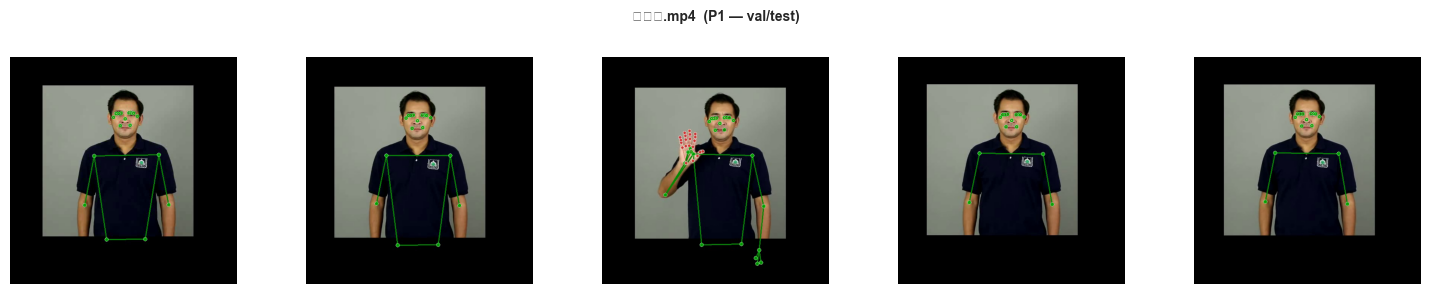

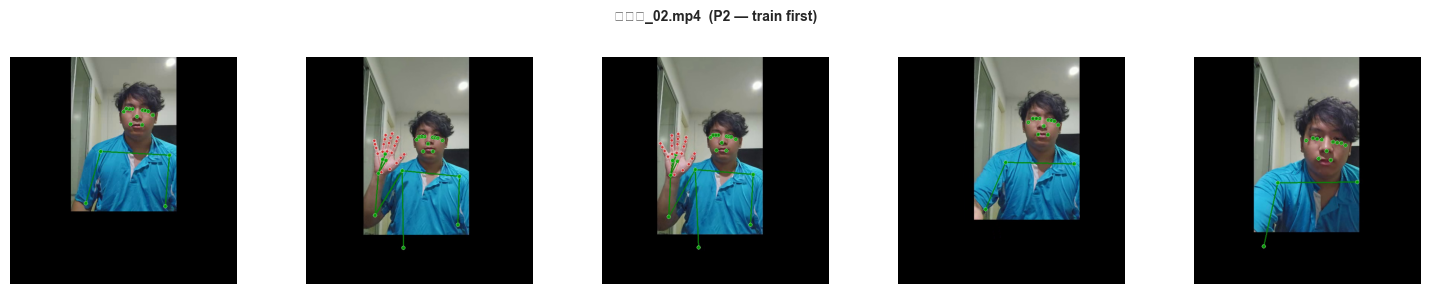

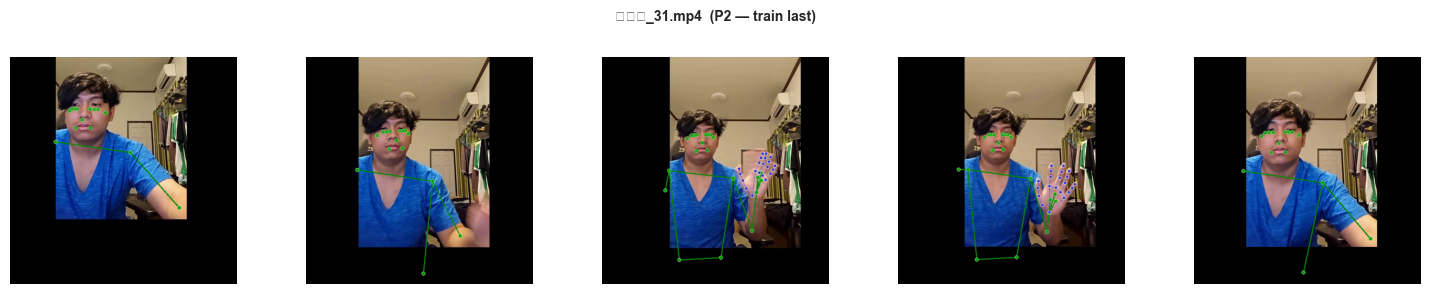


────────────────────────────────────────────────────────────
Class: ไม่ดี


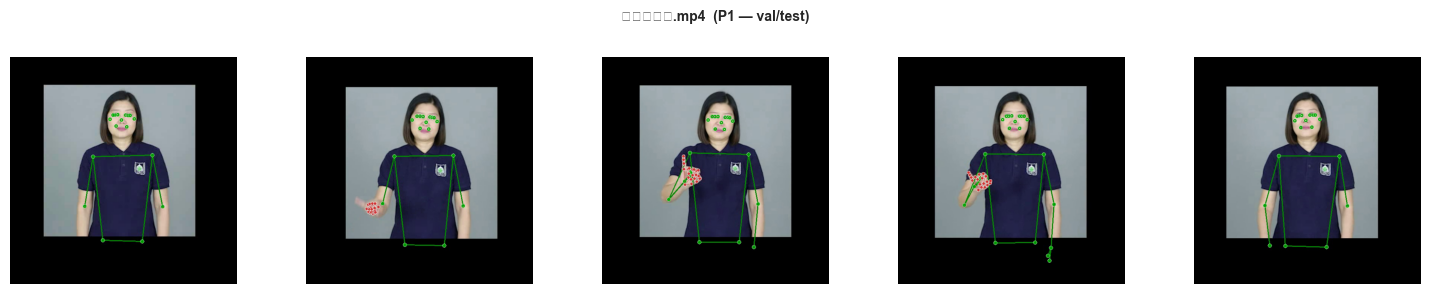

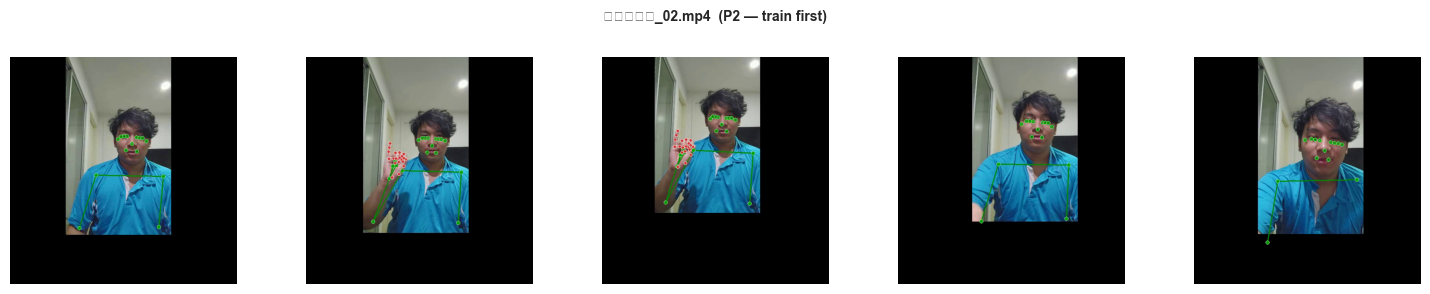

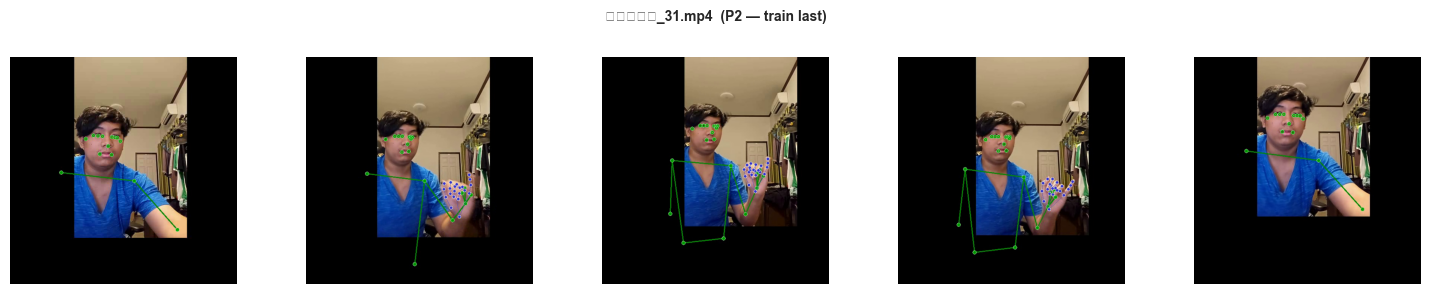

In [8]:
for cls in classes:
    print(f'\n{_SEP}')
    print(f'Class: {cls}')
    for suffix, label in VALIDATE_SUFFIXES:
        vid = MEDIAPIPE_DIR / f'{cls}{suffix}.mp4'
        show_video_strip(f'{cls}{suffix}.mp4  ({label})', vid, N_PREVIEW)


---
## Stage 5 — Keypoint Extraction

Extract per-frame landmarks from every cropped video using **MediaPipe Holistic**.

Feature vector per frame (`TOTAL_FEAT = 171`):

| Slice | Source | Size |
|-------|--------|------|
| `[0:63]` | Left hand (21 lm × xyz) | 63 |
| `[63:126]` | Right hand (21 lm × xyz) | 63 |
| `[126:171]` | Upper-body pose (15 lm × xyz) | 45 |

Missing hand → zero-padded. Sequences are resampled to `TARGET_FRAMES`.


In [5]:
def _lm_to_array(landmark_list, n_lm: int = 21) -> np.ndarray:
    """Convert a MediaPipe landmark list to a (n_lm*3,) float32 array."""
    if landmark_list is None:
        return np.zeros(n_lm * 3, dtype=np.float32)
    arr = np.array([[lm.x, lm.y, lm.z] for lm in landmark_list.landmark],
                   dtype=np.float32).flatten()
    return arr


def _pose_upper_to_array(pose_landmarks) -> np.ndarray:
    """Extract upper-body pose landmarks as (N_POSE_LM*3,) float32 array."""
    if pose_landmarks is None:
        return np.zeros(N_POSE_LM * 3, dtype=np.float32)
    lms = pose_landmarks.landmark
    rows = [[lms[i].x, lms[i].y, lms[i].z] for i in UPPER_BODY_POSE_IDX]
    return np.array(rows, dtype=np.float32).flatten()


def _pose_upper_visibility(pose_landmarks) -> np.ndarray:
    """Extract visibility scores for upper-body pose landmarks."""
    if pose_landmarks is None:
        return np.zeros(N_POSE_LM, dtype=np.float32)
    lms = pose_landmarks.landmark
    return np.array([lms[i].visibility for i in UPPER_BODY_POSE_IDX], dtype=np.float32)


def extract_keypoints_from_video(video_path: Path) -> tuple:
    """
    Run MediaPipe Holistic on a video and return:
        keypoints  : np.ndarray  shape (n_frames_raw, TOTAL_FEAT)
        confidence : np.ndarray  shape (n_frames_raw, CONF_FEAT)
    Returns (None, None) on failure.
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return None, None

    kp_rows, cf_rows = [], []

    with mp_holistic.Holistic(
        static_image_mode=False,
        model_complexity=1,
        smooth_landmarks=True,
        refine_face_landmarks=False,
        min_detection_confidence=0.4,
        min_tracking_confidence=0.4,
    ) as holistic:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            results = holistic.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

            lh_arr   = _lm_to_array(results.left_hand_landmarks)
            rh_arr   = _lm_to_array(results.right_hand_landmarks)
            pose_arr = _pose_upper_to_array(results.pose_landmarks)
            kp_rows.append(np.concatenate([lh_arr, rh_arr, pose_arr]))

            vis  = _pose_upper_visibility(results.pose_landmarks)
            lhf  = float(results.left_hand_landmarks  is not None)
            rhf  = float(results.right_hand_landmarks is not None)
            cf_rows.append(np.append(vis, [lhf, rhf]))

    cap.release()

    if not kp_rows:
        return None, None

    return np.stack(kp_rows), np.stack(cf_rows)


print('Stage 5 helpers loaded.')
print(f'  TOTAL_FEAT={TOTAL_FEAT}  CONF_FEAT={CONF_FEAT}')


Stage 5 helpers loaded.
  TOTAL_FEAT=171  CONF_FEAT=17


In [12]:
raw_keypoints  = {}   # key: (class, index) -> keypoints  ndarray (frames_raw, TOTAL_FEAT)
raw_confidence = {}   # key: (class, index) -> confidence ndarray (frames_raw, CONF_FEAT)
kp_meta        = []

for _, row in tqdm(df_cut.iterrows(), total=len(df_cut), desc='Stage 5 — keypoint extraction'):
    kp, cf = extract_keypoints_from_video(row['path'])
    key = (row['class'], row['index'])
    if kp is None:
        kp_meta.append({'class': row['class'], 'index': row['index'],
                        'person': row['person'], 'success': False})
        continue
    raw_keypoints[key]  = kp
    raw_confidence[key] = cf
    kp_meta.append({
        'class': row['class'], 'index': row['index'], 'person': row['person'],
        'success': True, 'n_frames_raw': len(kp),
        'lh_rate': cf[:, -2].mean(), 'rh_rate': cf[:, -1].mean(),
        'pose_vis_mean': cf[:, :-2].mean(),
    })

df_kp = pd.DataFrame(kp_meta)
print(f'Extracted  : {df_kp["success"].sum()} / {len(df_kp)} videos')
print(f'Failed     : {(~df_kp["success"]).sum()}')
if 'lh_rate' in df_kp.columns:
    ok = df_kp[df_kp['success']]
    print(f'Left-hand  detection — mean: {ok["lh_rate"].mean():.3f}')
    print(f'Right-hand detection — mean: {ok["rh_rate"].mean():.3f}')
    print(f'Pose visibility      — mean: {ok["pose_vis_mean"].mean():.3f}')


Stage 5 — keypoint extraction:   0%|          | 0/600 [00:00<?, ?it/s]

Extracted  : 600 / 600 videos
Failed     : 0
Left-hand  detection — mean: 0.383
Right-hand detection — mean: 0.236
Pose visibility      — mean: 0.550


---
## Stage 6 — Confidence Features Analysis

Analyse and visualise the confidence/visibility metrics collected alongside keypoints.

Confidence features per frame (`CONF_FEAT = 17`):
- `[0:15]` — pose landmark visibility scores (upper body)
- `[15]`   — left hand present (0/1)
- `[16]`   — right hand present (0/1)


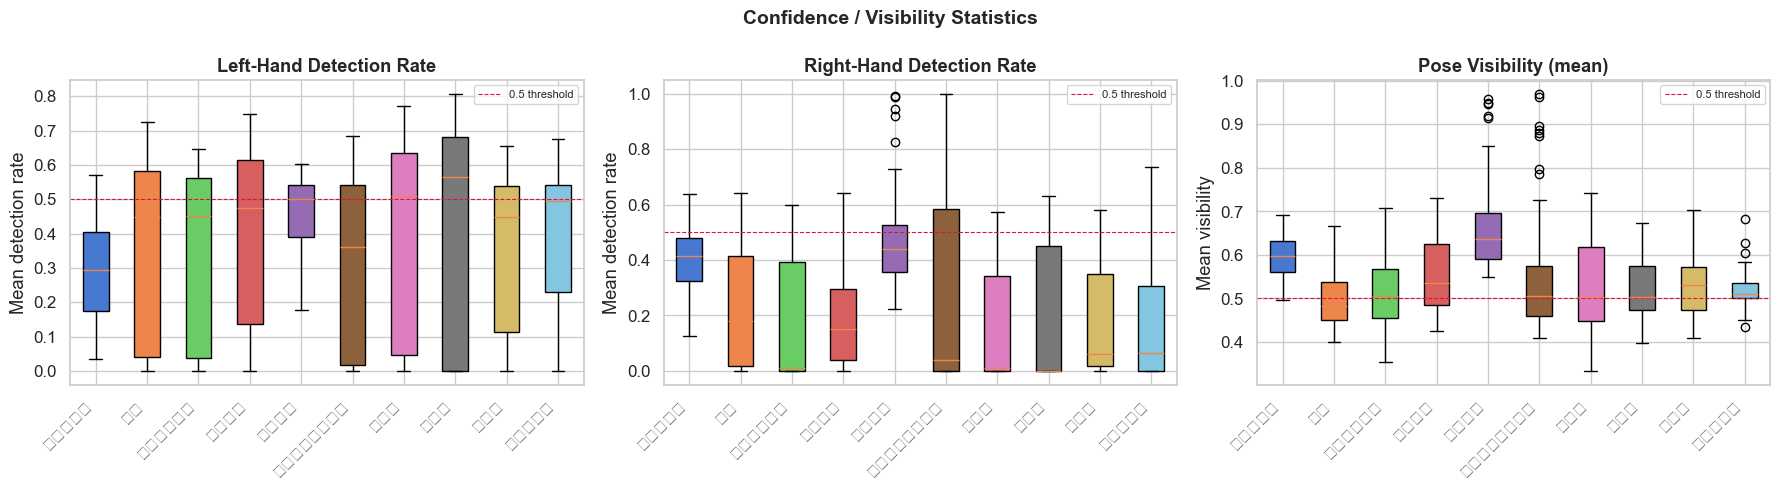

Videos with <30 % left-hand  detection: 202
Videos with <30 % right-hand detection: 349
Saved → logs/preprocessing/confidence_per_video.csv


In [13]:
ok_kp = df_kp[df_kp['success']].copy()

# Per-class mean detection rates
class_det = ok_kp.groupby('class')[['lh_rate', 'rh_rate', 'pose_vis_mean']].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confidence / Visibility Statistics', fontsize=14, fontweight='bold')

palette = sns.color_palette('muted', len(classes))

for ax, col, title, ylbl in [
    (axes[0], 'lh_rate',       'Left-Hand Detection Rate',  'Mean detection rate'),
    (axes[1], 'rh_rate',       'Right-Hand Detection Rate', 'Mean detection rate'),
    (axes[2], 'pose_vis_mean', 'Pose Visibility (mean)',    'Mean visibility'),
]:
    vals = [ok_kp[ok_kp['class'] == c][col].values for c in classes]
    bp = ax.boxplot(vals, labels=classes, patch_artist=True)
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylbl)
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.axhline(0.5, color='crimson', linestyle='--', linewidth=0.8, label='0.5 threshold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(LOGS_DIR / 'confidence_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag videos with poor hand coverage
poor_lh = ok_kp[ok_kp['lh_rate'] < 0.3]
poor_rh = ok_kp[ok_kp['rh_rate'] < 0.3]
print(f'Videos with <30 % left-hand  detection: {len(poor_lh)}')
print(f'Videos with <30 % right-hand detection: {len(poor_rh)}')

# Save confidence stats
ok_kp.to_csv(LOGS_DIR / 'confidence_per_video.csv', index=False, encoding='utf-8-sig')
print('Saved → logs/preprocessing/confidence_per_video.csv')


---
## Stage 7 — Keypoint Normalization

Applied in sequence:

1. **Wrist-centred coordinates** — hand landmarks shifted so wrist = origin.  
2. **Scale normalization** — divide by shoulder width (from pose) to remove camera-distance variance.  
3. **Pose translation normalization** — subtract midpoint of shoulders so pose is body-relative.  
4. **Sequence resampling** — resample every sequence to `TARGET_FRAMES` via linear interpolation.  


In [14]:
# Feature slice indices
_LH_SLICE   = slice(0,           HAND_FEAT)           # left hand xyz  [0:63]
_RH_SLICE   = slice(HAND_FEAT,   HAND_FEAT * 2)       # right hand xyz [63:126]
_POSE_SLICE = slice(HAND_FEAT*2, TOTAL_FEAT)           # pose xyz       [126:171]

# Pose landmark positions within the upper-body subset (local index inside UPPER_BODY_POSE_IDX)
_POSE_NOSE_IDX  = UPPER_BODY_POSE_IDX.index(0)    # 0
_POSE_LSHO_IDX  = UPPER_BODY_POSE_IDX.index(11)   # left shoulder
_POSE_RSHO_IDX  = UPPER_BODY_POSE_IDX.index(12)   # right shoulder
_POSE_LWRI_IDX  = UPPER_BODY_POSE_IDX.index(15)   # left wrist
_POSE_RWRI_IDX  = UPPER_BODY_POSE_IDX.index(16)   # right wrist


def normalize_keypoints(seq: np.ndarray, conf: np.ndarray) -> np.ndarray:
    """
    Apply full normalization pipeline to a (n_frames, TOTAL_FEAT) sequence.
    Returns normalised (n_frames, TOTAL_FEAT) array.
    """
    seq = seq.copy()
    pose = seq[:, _POSE_SLICE].reshape(-1, N_POSE_LM, 3)   # (T, 15, 3)
    lh   = seq[:, _LH_SLICE  ].reshape(-1, N_HAND_LM, 3)  # (T, 21, 3)
    rh   = seq[:, _RH_SLICE  ].reshape(-1, N_HAND_LM, 3)  # (T, 21, 3)

    # ── 1. Scale: shoulder width ──────────────────────────────────────────────
    lsho = pose[:, _POSE_LSHO_IDX, :2]   # (T, 2)
    rsho = pose[:, _POSE_RSHO_IDX, :2]
    shoulder_w = np.linalg.norm(lsho - rsho, axis=1, keepdims=True)  # (T, 1)
    # Use median across frames to avoid per-frame jitter; fallback=1.0
    scale = np.median(shoulder_w[shoulder_w > 1e-4])
    if scale < 1e-4:
        scale = 1.0

    # ── 2. Pose translation: midpoint of shoulders ────────────────────────────
    mid = ((lsho + rsho) / 2.0)[:, np.newaxis, :]  # (T,1,2) - xy only
    pose[:, :, :2] = (pose[:, :, :2] - mid) / scale
    pose[:, :,  2] = pose[:, :, 2]  / scale   # z scale only

    # ── 3. Wrist-centred hands ────────────────────────────────────────────────
    # Wrist = landmark index 0 in MediaPipe Hand
    lh_wrist = lh[:, 0:1, :]   # (T,1,3)
    rh_wrist = rh[:, 0:1, :]
    lh_pres  = conf[:, -2:  -1][:, np.newaxis, :]   # (T,1,1) hand present flag
    rh_pres  = conf[:,  -1:   ][:, np.newaxis, :]

    # Shift only when hand is detected; keep zeros for absent frames
    lh_cent = (lh - lh_wrist) / scale
    rh_cent = (rh - rh_wrist) / scale
    # Where hand absent: leave as zero vector
    lh = np.where(lh_pres > 0.5, lh_cent, 0.0)
    rh = np.where(rh_pres > 0.5, rh_cent, 0.0)

    seq[:, _LH_SLICE  ] = lh.reshape(-1, HAND_FEAT)
    seq[:, _RH_SLICE  ] = rh.reshape(-1, HAND_FEAT)
    seq[:, _POSE_SLICE] = pose.reshape(-1, POSE_FEAT)
    return seq


print('Stage 7 normalization helpers loaded.')


Stage 7 normalization helpers loaded.


Stage 7 — normalizing:   0%|          | 0/600 [00:00<?, ?it/s]

Normalised sequences : 600
Shape per sample     : (240, 171)   (TARGET_FRAMES=240, TOTAL_FEAT=171)
Value range          : [-5.4012, 1.7110]


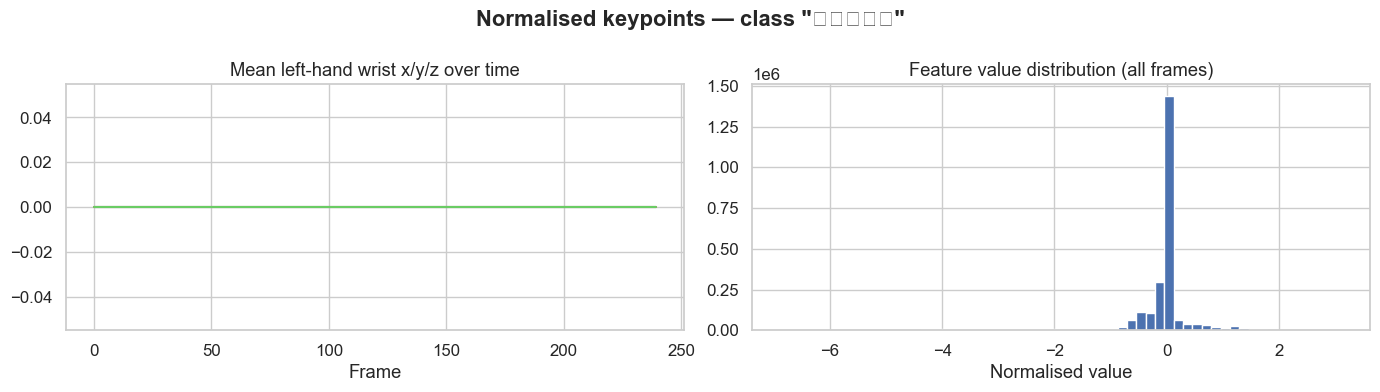

In [15]:
norm_keypoints = {}   # (class, index) -> (TARGET_FRAMES, TOTAL_FEAT)

for key, kp in tqdm(raw_keypoints.items(), desc='Stage 7 — normalizing'):
    cf = raw_confidence[key]
    norm  = normalize_keypoints(kp, cf)
    resampled = resample_sequence(norm, TARGET_FRAMES)
    norm_keypoints[key] = resampled.astype(np.float32)

print(f'Normalised sequences : {len(norm_keypoints)}')
if norm_keypoints:
    sample_val = next(iter(norm_keypoints.values()))
    print(f'Shape per sample     : {sample_val.shape}   (TARGET_FRAMES={TARGET_FRAMES}, TOTAL_FEAT={TOTAL_FEAT})')
    print(f'Value range          : [{sample_val.min():.4f}, {sample_val.max():.4f}]')

# Quick sanity: plot feature statistics for one class
_cls_example = classes[0]
_seqs = [v for (c, _), v in norm_keypoints.items() if c == _cls_example]
if _seqs:
    _stacked = np.stack(_seqs)   # (N, T, F)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Normalised keypoints — class "{_cls_example}"', fontweight='bold')
    axes[0].plot(_stacked[:, :, :3].mean(axis=0))    # mean left wrist x,y,z over time
    axes[0].set_title('Mean left-hand wrist x/y/z over time')
    axes[0].set_xlabel('Frame')
    axes[1].hist(_stacked.flatten(), bins=60, color='#4C72B0', edgecolor='white')
    axes[1].set_title('Feature value distribution (all frames)')
    axes[1].set_xlabel('Normalised value')
    plt.tight_layout()
    plt.savefig(LOGS_DIR / 'normalisation_sanity.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## Stage 8 — Data Augmentation (training split only)

Applied **only to P2 videos** (indices 02–31).  
Each training video generates `N_AUG_VARIANTS` augmented copies.

| Augmentation | Parameter |
|---|---|
| Speed jitter | ±15 % (resample frames) |
| Scale jitter | ±5 % |
| Translation jitter | ±5 % |
| Rotation | ±5° (xy plane) |
| Horizontal flip | swap left ↔ right hands |
| Gaussian noise | std = 0.005 |


In [16]:
rng = np.random.default_rng(42)


def aug_speed(seq: np.ndarray, jitter: float = SPEED_JITTER) -> np.ndarray:
    """Resample sequence to simulate ±jitter speed change, then resize back."""
    factor = 1.0 + rng.uniform(-jitter, jitter)
    new_len = max(2, int(round(len(seq) * factor)))
    tmp = resample_sequence(seq, new_len)
    return resample_sequence(tmp, len(seq))   # restore original length


def aug_scale(seq: np.ndarray, jitter: float = SCALE_JITTER) -> np.ndarray:
    """Multiply all coordinate values by a small random scale."""
    s = 1.0 + rng.uniform(-jitter, jitter)
    return seq * s


def aug_translate(seq: np.ndarray, jitter: float = TRANS_JITTER) -> np.ndarray:
    """Add a small random offset to x and y coordinates."""
    out = seq.copy()
    for slc in [_LH_SLICE, _RH_SLICE, _POSE_SLICE]:
        block = out[:, slc].reshape(len(seq), -1, 3)
        dx = rng.uniform(-jitter, jitter)
        dy = rng.uniform(-jitter, jitter)
        block[:, :, 0] += dx
        block[:, :, 1] += dy
        out[:, slc] = block.reshape(len(seq), -1)
    return out


def aug_rotate(seq: np.ndarray, max_deg: float = ROT_JITTER) -> np.ndarray:
    """Rotate xy coordinates around the origin by a small random angle."""
    theta = rng.uniform(-max_deg, max_deg) * np.pi / 180.0
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    out = seq.copy()
    for slc in [_LH_SLICE, _RH_SLICE, _POSE_SLICE]:
        block = out[:, slc].reshape(len(seq), -1, 3)
        x = block[:, :, 0].copy()
        y = block[:, :, 1].copy()
        block[:, :, 0] = cos_t * x - sin_t * y
        block[:, :, 1] = sin_t * x + cos_t * y
        out[:, slc] = block.reshape(len(seq), -1)
    return out


def aug_flip(seq: np.ndarray) -> np.ndarray:
    """Horizontal mirror: negate x, swap left ↔ right hand blocks."""
    out = seq.copy()
    # Negate x for all blocks
    for slc in [_LH_SLICE, _RH_SLICE, _POSE_SLICE]:
        block = out[:, slc].reshape(len(seq), -1, 3)
        block[:, :, 0] *= -1
        out[:, slc] = block.reshape(len(seq), -1)
    # Swap left ↔ right hand blocks
    lh_tmp = out[:, _LH_SLICE].copy()
    out[:, _LH_SLICE] = out[:, _RH_SLICE]
    out[:, _RH_SLICE] = lh_tmp
    return out


def aug_noise(seq: np.ndarray, std: float = NOISE_STD) -> np.ndarray:
    """Add small Gaussian noise to all keypoints."""
    return seq + rng.normal(0, std, size=seq.shape).astype(np.float32)


_ALL_AUGS = [
    ('speed',     aug_speed),
    ('scale',     aug_scale),
    ('translate', aug_translate),
    ('rotate',    aug_rotate),
    ('flip',      aug_flip),
    ('noise',     aug_noise),
]


def augment_once(seq: np.ndarray) -> np.ndarray:
    """Apply a random combination of augmentations to one sequence."""
    out = seq.copy()
    # Always apply noise; randomly apply each other aug with p=0.5
    for name, fn in _ALL_AUGS:
        if name == 'noise' or rng.random() < 0.5:
            out = fn(out)
    return out.astype(np.float32)


print('Stage 8 augmentation helpers loaded.')
print(f'  N_AUG_VARIANTS = {N_AUG_VARIANTS}')


Stage 8 augmentation helpers loaded.
  N_AUG_VARIANTS = 3


In [17]:
aug_keypoints = {}   # (class, index, aug_id) -> (TARGET_FRAMES, TOTAL_FEAT)
                     # aug_id=0 → original; 1..N → augmented

for (cls, idx), seq in tqdm(norm_keypoints.items(), desc='Stage 8 — augmentation'):
    # Determine split for this video
    is_train = P2_START <= idx <= P2_END

    # Always keep original
    aug_keypoints[(cls, idx, 0)] = seq

    # Add augmented variants for training videos only
    if is_train:
        for aug_id in range(1, N_AUG_VARIANTS + 1):
            aug_keypoints[(cls, idx, aug_id)] = augment_once(seq)

n_train_orig = sum(1 for (_, idx, aid) in aug_keypoints if P2_START <= idx <= P2_END and aid == 0)
n_train_aug  = sum(1 for (_, idx, aid) in aug_keypoints if P2_START <= idx <= P2_END and aid > 0)
n_valtest    = sum(1 for (_, idx, aid) in aug_keypoints if not (P2_START <= idx <= P2_END))

print(f'Training originals  : {n_train_orig}')
print(f'Training augmented  : {n_train_aug}   ({N_AUG_VARIANTS}× per video)')
print(f'Val/test (no aug)   : {n_valtest}')
print(f'Total samples       : {len(aug_keypoints)}')


Stage 8 — augmentation:   0%|          | 0/600 [00:00<?, ?it/s]

Training originals  : 300
Training augmented  : 900   (3× per video)
Val/test (no aug)   : 300
Total samples       : 1500


---
## Stage 9 — Dataset Split

**Identity-based split** (prevents same signer appearing in both train and val/test):

| Split | Videos |
|-------|--------|
| **train** | `word_02.mp4` … `word_31.mp4` (P2, 30 per class) + augmented copies |
| **val**   | `word.mp4` + `word_32.mp4` … `word_46.mp4` (P1 + P3 first half) |
| **test**  | `word_47.mp4` … `word_60.mp4` (P3 second half) |


Dataset split:
  Train : X=(1200, 240, 171)  y=(1200,)
  Val   : X=(160, 240, 171)  y=(160,)
  Test  : X=(140, 240, 171)  y=(140,)
  Classes: {'ขอโทษ': 0, 'ดี': 1, 'สวัสดี': 2, 'อะไร': 3, 'เงิน': 4, 'โทรศัพท์': 5, 'ใคร': 6, 'ใช่': 7, 'ไม่': 8, 'ไม่ดี': 9}


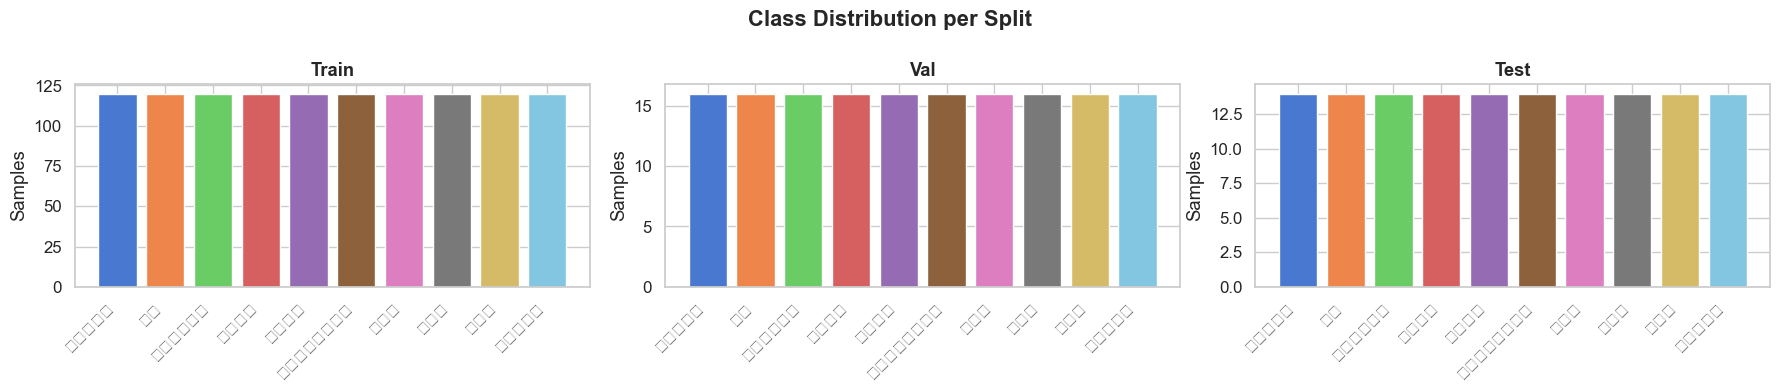

In [18]:
VAL_P3_END = 46   # word_32 … word_46 go to val; word_47 … word_60 go to test


def get_split(idx: int) -> str:
    if P2_START <= idx <= P2_END:
        return 'train'
    if idx == 1 or (P3_START <= idx <= VAL_P3_END):
        return 'val'
    return 'test'


class_to_label = {cls: i for i, cls in enumerate(classes)}

X_train, y_train = [], []
X_val,   y_val   = [], []
X_test,  y_test  = [], []
meta_train, meta_val, meta_test = [], [], []

for (cls, idx, aug_id), seq in aug_keypoints.items():
    split  = get_split(idx)
    label  = class_to_label[cls]
    record = {'class': cls, 'index': idx, 'aug_id': aug_id, 'label': label, 'split': split}

    if split == 'train':
        X_train.append(seq); y_train.append(label); meta_train.append(record)
    elif split == 'val':
        X_val.append(seq);   y_val.append(label);   meta_val.append(record)
    else:
        X_test.append(seq);  y_test.append(label);  meta_test.append(record)

X_train = np.stack(X_train).astype(np.float32)
X_val   = np.stack(X_val  ).astype(np.float32)
X_test  = np.stack(X_test ).astype(np.float32)
y_train = np.array(y_train, dtype=np.int64)
y_val   = np.array(y_val,   dtype=np.int64)
y_test  = np.array(y_test,  dtype=np.int64)

print('Dataset split:')
print(f'  Train : X={X_train.shape}  y={y_train.shape}')
print(f'  Val   : X={X_val.shape  }  y={y_val.shape  }')
print(f'  Test  : X={X_test.shape }  y={y_test.shape }')
print(f'  Classes: {class_to_label}')

# Class balance check
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Class Distribution per Split', fontweight='bold')
for ax, y, title in [(axes[0], y_train, 'Train'), (axes[1], y_val, 'Val'), (axes[2], y_test, 'Test')]:
    unique, counts = np.unique(y, return_counts=True)
    ax.bar([classes[u] for u in unique], counts, color=sns.color_palette('muted', len(unique)))
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Samples')
    ax.set_xticklabels([classes[u] for u in unique], rotation=45, ha='right')
plt.tight_layout()
plt.savefig(LOGS_DIR / 'dataset_split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Stage 10 — Save Processed Dataset

Saves to `datasets/processed/`:
- `X_train.npy`, `y_train.npy`
- `X_val.npy`,   `y_val.npy`
- `X_test.npy`,  `y_test.npy`
- `dataset.npz` — all splits in one archive
- `metadata.parquet` — per-sample metadata
- `class_labels.json` — class index mapping


In [19]:
# ── Save individual npy files ──────────────────────────────────────────────────
for name, arr in [
    ('X_train', X_train), ('y_train', y_train),
    ('X_val',   X_val  ), ('y_val',   y_val  ),
    ('X_test',  X_test ), ('y_test',  y_test ),
]:
    p = PROCESSED_DIR / f'{name}.npy'
    np.save(str(p), arr)
    print(f'Saved {name:10s} → {p}  shape={arr.shape}  dtype={arr.dtype}')

# ── Save combined npz archive ──────────────────────────────────────────────────
npz_path = PROCESSED_DIR / 'dataset.npz'
np.savez_compressed(
    str(npz_path),
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
)
print(f'\nSaved combined archive → {npz_path}')

# ── Save per-sample metadata as parquet ───────────────────────────────────────
df_meta_all = pd.DataFrame(meta_train + meta_val + meta_test)
df_meta_all['is_augmented'] = df_meta_all['aug_id'] > 0
meta_path = PROCESSED_DIR / 'metadata.parquet'
df_meta_all.to_parquet(str(meta_path), index=False)
print(f'Saved metadata         → {meta_path}  ({len(df_meta_all)} rows)')

# ── Save class label mapping ───────────────────────────────────────────────────
label_map = {
    'class_to_label': class_to_label,
    'label_to_class': {str(v): k for k, v in class_to_label.items()},
    'classes': classes,
}
label_path = PROCESSED_DIR / 'class_labels.json'
with open(label_path, 'w', encoding='utf-8') as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)
print(f'Saved class labels     → {label_path}')

# ── Save feature config metadata ───────────────────────────────────────────────
feature_config = {
    'TOTAL_FEAT': TOTAL_FEAT,
    'CONF_FEAT': CONF_FEAT,
    'TARGET_FRAMES': TARGET_FRAMES,
    'TARGET_SIZE': TARGET_SIZE,
    'HAND_FEAT': HAND_FEAT,
    'POSE_FEAT': POSE_FEAT,
    'N_HAND_LM': N_HAND_LM,
    'N_POSE_LM': N_POSE_LM,
    'UPPER_BODY_POSE_IDX': UPPER_BODY_POSE_IDX,
    'feature_slices': {
        'left_hand_xyz':   [0, HAND_FEAT],
        'right_hand_xyz':  [HAND_FEAT, HAND_FEAT * 2],
        'pose_upper_xyz':  [HAND_FEAT * 2, TOTAL_FEAT],
    },
    'N_AUG_VARIANTS': N_AUG_VARIANTS,
    'split_boundaries': {
        'train': [P2_START, P2_END],
        'val':   [1, VAL_P3_END],
        'test':  [VAL_P3_END + 1, P3_END],
    },
}
cfg_path = PROCESSED_DIR / 'feature_config.json'
with open(cfg_path, 'w', encoding='utf-8') as f:
    json.dump(feature_config, f, indent=2)
print(f'Saved feature config   → {cfg_path}')

print('\n✓ Stage 10 complete.')


Saved X_train    → ..\datasets\processed\X_train.npy  shape=(1200, 240, 171)  dtype=float32
Saved y_train    → ..\datasets\processed\y_train.npy  shape=(1200,)  dtype=int64
Saved X_val      → ..\datasets\processed\X_val.npy  shape=(160, 240, 171)  dtype=float32
Saved y_val      → ..\datasets\processed\y_val.npy  shape=(160,)  dtype=int64
Saved X_test     → ..\datasets\processed\X_test.npy  shape=(140, 240, 171)  dtype=float32
Saved y_test     → ..\datasets\processed\y_test.npy  shape=(140,)  dtype=int64

Saved combined archive → ..\datasets\processed\dataset.npz
Saved metadata         → ..\datasets\processed\metadata.parquet  (1500 rows)
Saved class labels     → ..\datasets\processed\class_labels.json
Saved feature config   → ..\datasets\processed\feature_config.json

✓ Stage 10 complete.


---
## Preprocessing Statistics

Save a comprehensive report to `logs/preprocessing/`.


Report saved → ..\logs\preprocessing\preprocessing_report.json


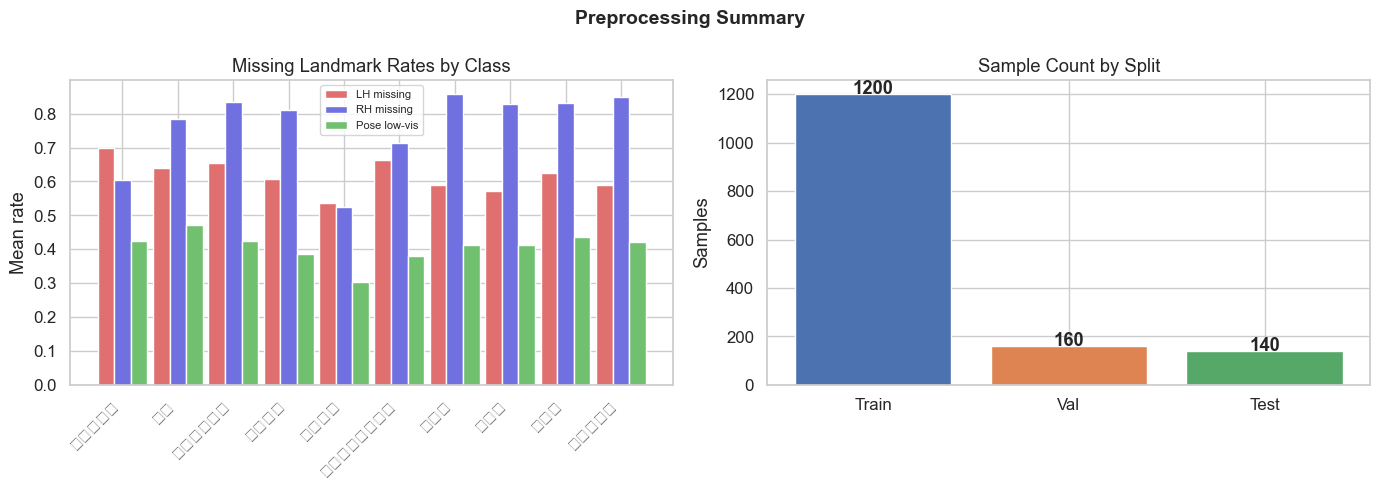


  PREPROCESSING COMPLETE
  Train : (1200, 240, 171)  (3 aug variants per video)
  Val   : (160, 240, 171)
  Test  : (140, 240, 171)
  Saved to: C:\Users\Napat\termtemsl\experiment_model\datasets\processed
  Logs at : C:\Users\Napat\termtemsl\experiment_model\logs\preprocessing


In [24]:
import datetime

# ── Missing landmark ratios ────────────────────────────────────────────────────
missing_stats = []
for key, cf in raw_confidence.items():
    cls, idx = key
    missing_stats.append({
        'class': cls, 'index': idx,
        'split': get_split(idx),
        'n_frames': len(cf),
        'lh_missing_rate':   1.0 - float(cf[:, -2].mean()),
        'rh_missing_rate':   1.0 - float(cf[:, -1].mean()),
        'pose_low_vis_rate': float((cf[:, :-2].mean(axis=1) < 0.5).mean()),
    })

df_missing = pd.DataFrame(missing_stats)
df_missing.to_csv(LOGS_DIR / 'missing_landmark_ratios.csv', index=False, encoding='utf-8-sig')

# ── Detection failure rates per class ─────────────────────────────────────────
det_summary = df_missing.groupby('class').agg(
    lh_missing_mean=('lh_missing_rate',   'mean'),
    rh_missing_mean=('rh_missing_rate',   'mean'),
    pose_low_mean  =('pose_low_vis_rate', 'mean'),
).round(4)

# ── Stage 1 crop statistics ────────────────────────────────────────────────────
s1_stats_path = LOGS_DIR / 'stage1_crop_stats.csv'
df_s1.to_csv(str(s1_stats_path), index=False, encoding='utf-8-sig')

# ── Compile full report ────────────────────────────────────────────────────────
report = {
    'generated_at': datetime.datetime.now().isoformat(),
    'config': {
        'TARGET_SIZE': TARGET_SIZE,
        'TARGET_FRAMES': TARGET_FRAMES,
        'POSE_MARGIN': POSE_MARGIN,
        'SMOOTH_WINDOW': SMOOTH_WINDOW,
        'N_AUG_VARIANTS': N_AUG_VARIANTS,
    },
    'stage1_centering': {
        'total_videos': int(len(df_s1)),
        'success_count': int(df_s1['success'].sum()) if 'success' in df_s1.columns else None,
        'mean_detection_rate': float(df_s1['detection_rate'].mean()) if 'detection_rate' in df_s1.columns else None,
        'videos_below_50pct': int((df_s1['detection_rate'].fillna(1.0) < 0.5).sum()) if 'detection_rate' in df_s1.columns else None,
    },
    'stage5_extraction': {
        'total_videos': int(len(df_kp)),
        'success_count': int(df_kp['success'].sum()),
        'mean_lh_detection': float(df_kp['lh_rate'].mean()) if 'lh_rate' in df_kp.columns else None,
        'mean_rh_detection': float(df_kp['rh_rate'].mean()) if 'rh_rate' in df_kp.columns else None,
    },
    'missing_landmark_summary': {
        'mean_lh_missing': float(df_missing['lh_missing_rate'].mean()),
        'mean_rh_missing': float(df_missing['rh_missing_rate'].mean()),
        'mean_pose_low_vis': float(df_missing['pose_low_vis_rate'].mean()),
    },
    'dataset_split': {
        'train_samples': int(len(y_train)),
        'val_samples':   int(len(y_val)),
        'test_samples':  int(len(y_test)),
        'total_samples': int(len(y_train) + len(y_val) + len(y_test)),
    },
    'feature_shape': {
        'X_train': list(X_train.shape),
        'X_val':   list(X_val.shape),
        'X_test':  list(X_test.shape),
    },
}

report_path = LOGS_DIR / 'preprocessing_report.json'
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=2)
print(f'Report saved → {report_path}')

# ── Summary figure ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Preprocessing Summary', fontsize=14, fontweight='bold')

ax = axes[0]
x = np.arange(len(classes))
w = 0.3
ax.bar(x - w, det_summary['lh_missing_mean'], w, label='LH missing', color='#E07070')
ax.bar(x,     det_summary['rh_missing_mean'], w, label='RH missing', color='#7070E0')
ax.bar(x + w, det_summary['pose_low_mean'],   w, label='Pose low-vis', color='#70C070')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_ylabel('Mean rate')
ax.set_title('Missing Landmark Rates by Class')
ax.legend(fontsize=8)

ax = axes[1]
split_counts = {'Train': len(y_train), 'Val': len(y_val), 'Test': len(y_test)}
ax.bar(split_counts.keys(), split_counts.values(),
       color=['#4C72B0', '#DD8452', '#55A868'])
for rect, v in zip(ax.patches, split_counts.values()):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 1,
            str(v), ha='center', fontweight='bold')
ax.set_title('Sample Count by Split')
ax.set_ylabel('Samples')

plt.tight_layout()
plt.savefig(LOGS_DIR / 'preprocessing_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '=' * 60)
print('  PREPROCESSING COMPLETE')
print('=' * 60)
print(f'  Train : {X_train.shape}  ({N_AUG_VARIANTS} aug variants per video)')
print(f'  Val   : {X_val.shape}')
print(f'  Test  : {X_test.shape}')
print(f'  Saved to: {PROCESSED_DIR.resolve()}')
print(f'  Logs at : {LOGS_DIR.resolve()}')
print('=' * 60)
